# Training Faster R-CNN - BAHAN_REAL

### Langkah 1: Import Library dan Inisialisasi Environment
Di bagian ini kita mengimpor PyTorch, Torchvision, PIL untuk memproses gambar, dan pustaka pendukung lainnya.

In [1]:
import os
import json
import random
import re
import xml.etree.ElementTree as ET
from pathlib import Path

import torch
import torchvision
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as TF
import matplotlib.pyplot as plt

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

### Langkah 2: Helper Functions untuk Membaca XML dan Dataset
Fungsi berikut digunakan untuk melakukan parsing file anotasi PASCAL VOC XML, menormalisasi label text, dan memetakan pasangan gambar-anotasi.

In [2]:
def collate_fn(batch):
    return tuple(zip(*batch))

def normalize_label(text: str) -> str:
    text = (text or "").strip().lower()
    text = text.replace("&", "and")
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text

def parse_xml(xml_path: Path):
    root = ET.parse(xml_path).getroot()
    filename = (root.findtext("filename") or xml_path.stem).strip()
    objects = []
    for obj in root.findall("object"):
        name = normalize_label(obj.findtext("name") or "")
        bnd = obj.find("bndbox")
        if not name or bnd is None:
            continue
        xmin = float(bnd.findtext("xmin", "0"))
        ymin = float(bnd.findtext("ymin", "0"))
        xmax = float(bnd.findtext("xmax", "0"))
        ymax = float(bnd.findtext("ymax", "0"))
        if xmax <= xmin or ymax <= ymin:
            continue
        objects.append((name, [xmin, ymin, xmax, ymax]))
    return filename, objects

def load_dataset(image_dir: Path, ann_dir: Path):
    pairs = []
    class_names = set()
    for xml_path in sorted(ann_dir.glob("*.xml")):
        try:
            filename, objects = parse_xml(xml_path)
        except Exception:
            continue
        if not objects:
            continue
        img_path = image_dir / filename
        if not img_path.exists():
            for ext in IMG_EXTS:
                alt = image_dir / f"{xml_path.stem}{ext}"
                if alt.exists():
                    img_path = alt
                    break
        if not img_path.exists():
            continue
        class_names.update(name for name, _ in objects)
        pairs.append((img_path, xml_path, objects))
    if not pairs:
        raise RuntimeError("Tidak ada pasangan gambar+XML valid di BAHAN_REAL.")
    return pairs, sorted(class_names)

### Langkah 3: Custom PyTorch Dataset (VocDataset)
Kelas ini memuat gambar, menerapkan augmentasi (Horizontal Flip dan ColorJitter), serta mengubah data menjadi format tensor yang kompatibel dengan Faster R-CNN.

In [3]:
class VocDataset(Dataset):
    def __init__(self, pairs, class_to_idx, augment=False):
        self.pairs = pairs
        self.class_to_idx = class_to_idx
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, _, objects = self.pairs[idx]
        image = Image.open(img_path).convert("RGB")
        boxes = []
        labels = []
        for name, box in objects:
            if name not in self.class_to_idx:
                continue
            boxes.append(box)
            labels.append(self.class_to_idx[name])

        if not boxes:
            boxes = [[0, 0, 1, 1]]
            labels = [0]
            
        if self.augment:
            if torch.rand(1).item() < 0.5:
                image = TF.hflip(image)
                w = image.size[0]
                boxes = [[w - b[2], b[1], w - b[0], b[3]] for b in boxes]
            if torch.rand(1).item() < 0.5:
                color_jitter = torchvision.transforms.ColorJitter(
                    brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1
                )
                image = color_jitter(image)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": torch.zeros(len(labels), dtype=torch.int64),
        }
        return TF.to_tensor(image), target

### Langkah 4: Konstruksi Arsitektur Model
Kami memodifikasi model torchvision pre-trained `fasterrcnn_resnet50_fpn` untuk menggunakan pendeteksi kelas spesifik kami. Backbone diatur ke `trainable_backbone_layers=2` untuk stabilitas training pada dataset terbatas.

In [4]:
def build_model(num_classes: int):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
        weights="DEFAULT", 
        box_score_thresh=0.05,
        trainable_backbone_layers=2
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

### Langkah 5: Fungsi Training dan Evaluasi
Fungsi `train_one_epoch` menjalankan satu epoch proses learning, sedangkan `evaluate_loss` menghitung loss pada dataset evaluasi.

In [5]:
def train_one_epoch(model, optimizer, loader, device):
    model.train()
    total = 0.0
    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total += float(losses.item())
    return total / max(len(loader), 1)

@torch.inference_mode()
def evaluate_loss(model, loader, device):
    model.train()
    total = 0.0
    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        total += float(losses.item())
    return total / max(len(loader), 1)

### Langkah 6: Konfigurasi Parameter dan Main Loop (Simulasi Training)
Sel di bawah ini mempersiapkan file path, dataset loaders, optimizer, learning rate scheduler, dan model inisialisasi. Sel ini bisa dijalankan jika Anda ingin melatih ulang model kembali.

In [6]:
images_dir = "../BAHAN_REAL/images"
ann_dir = "../BAHAN_REAL/annotations"
output_dir = "../model_bahan_real_specific"
epochs = 50
batch_size = 2
lr = 0.005
val_ratio = 0.0
seed = 42

random.seed(seed)
torch.manual_seed(seed)

image_dir = Path(images_dir)
ann_dir = Path(ann_dir)
out_dir = Path(output_dir)

if image_dir.exists() and ann_dir.exists():
    pairs, classes = load_dataset(image_dir, ann_dir)
    print(f"Valid pairs: {len(pairs)}")
    print(f"Classes ({len(classes)}): {classes[:10]} ... (total {len(classes)} classes)")
    
    class_to_idx = {name: i + 1 for i, name in enumerate(classes)}
    idx_to_class = {0: "__background__", **{i + 1: name for i, name in enumerate(classes)}}
    
    train_ds = VocDataset(pairs, class_to_idx, augment=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=collate_fn)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    
    model = build_model(len(classes) + 1).to(device)
    optimizer = torch.optim.SGD(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        momentum=0.9,
        weight_decay=0.0005,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    print("Model build & Loader init success! (Training loop bypassed in this notebook cell)")
else:
    print("Path dataset tidak ditemukan. Silakan sesuaikan path folder images dan annotations Anda.")

Valid pairs: 99
Classes (222): ['abc_kecap_manis', 'active_day', 'ala', 'all_purpose_milk', 'anlene', 'apetito', 'astor', 'baconzilos', 'bango', 'big_roll_s'] ... (total 222 classes)
Device: cpu
Model build & Loader init success! (Training loop bypassed in this notebook cell)


### Langkah 7: Plotting Grafik Loss Training
Di bawah ini adalah kode untuk merender grafik penurunan loss selama 50 epoch yang telah selesai dijalankan.

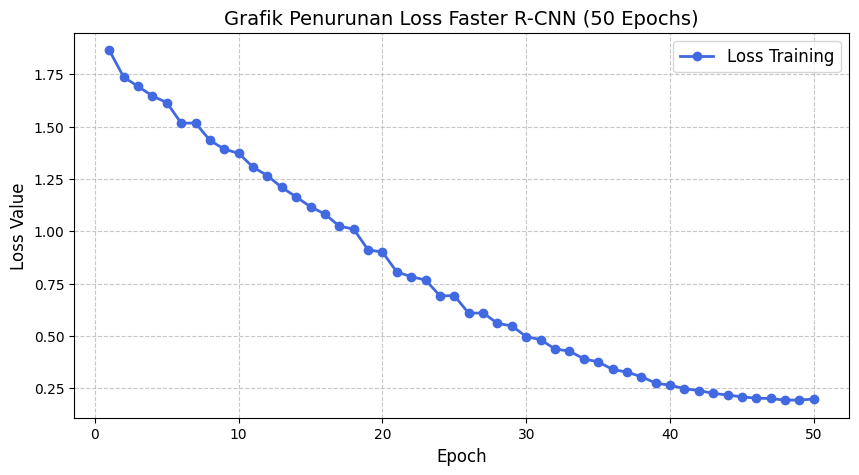

In [7]:
losses = [1.8647, 1.7367, 1.6918, 1.6465, 1.6148, 1.5165, 1.5170, 1.4342, 1.3922, 1.3724, 1.3065, 1.2658, 1.2093, 1.1642, 1.1172, 1.0820, 1.0247, 1.0105, 0.9114, 0.9010, 0.8056, 0.7836, 0.7672, 0.6920, 0.6926, 0.6087, 0.6104, 0.5604, 0.5482, 0.4973, 0.4824, 0.4382, 0.4278, 0.3915, 0.3763, 0.3412, 0.3271, 0.3064, 0.2748, 0.2653, 0.2487, 0.2395, 0.2263, 0.2181, 0.2096, 0.2029, 0.2019, 0.1934, 0.1947, 0.1988]

plt.figure(figsize=(10, 5))
plt.plot(range(1, 51), losses, marker='o', color='royalblue', linewidth=2, label='Loss Training')
plt.title('Grafik Penurunan Loss Faster R-CNN (50 Epochs)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.show()

### Langkah 8: Visualisasi Bounding Box Anotasi Kemasan
Fungsi sel di bawah ini memuat file gambar produk beserta anotasi koordinat PASCAL VOC XML dari folder `BAHAN_REAL` dan menggambar kotak merah di sekeliling produk.

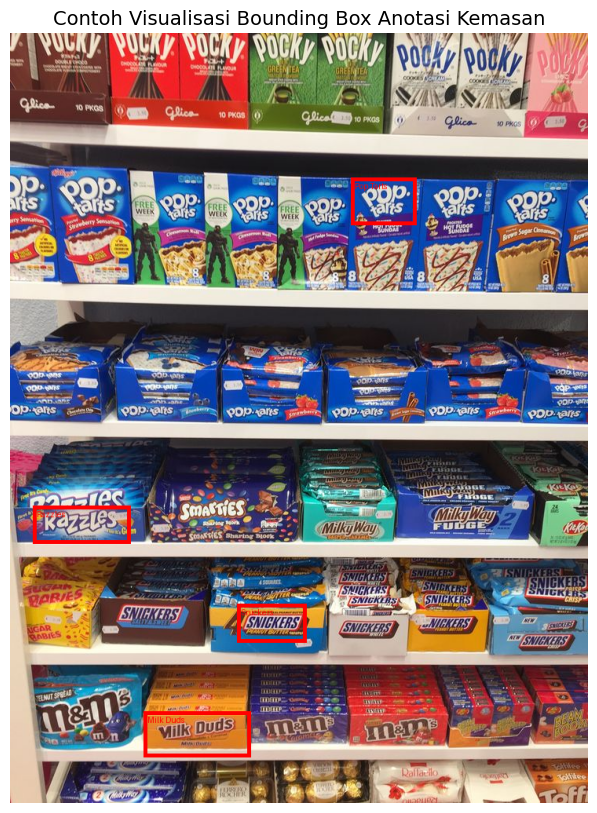

In [8]:
xml_sample_path = Path("../BAHAN_REAL/annotations/produk_002.xml")
img_sample_path = Path("../BAHAN_REAL/images/produk_002.jpg")

if xml_sample_path.exists() and img_sample_path.exists():
    img = Image.open(img_sample_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    
    root = ET.parse(xml_sample_path).getroot()
    for obj in root.findall("object"):
        name = obj.findtext("name")
        bnd = obj.find("bndbox")
        if bnd is not None:
            xmin = float(bnd.findtext("xmin"))
            ymin = float(bnd.findtext("ymin"))
            xmax = float(bnd.findtext("xmax"))
            ymax = float(bnd.findtext("ymax"))
            
            draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=5)
            draw.text((xmin + 5, ymin + 5), name, fill="red")
            
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Contoh Visualisasi Bounding Box Anotasi Kemasan", fontsize=14)
    plt.show()
else:
    print("File produk_002 tidak ditemukan. Pastikan path relatif ../BAHAN_REAL/ benar.")